##CS7DS2 - Optimisation Algorithms for Data Analysis - Week 2 Assignment

Name : Swetha Sekar

Student ID : 25336453



In [19]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

##Question - 1

In [20]:
#question 1 (a)

x = sp.symbols('x')
f = x**4
dfdx = sp.diff(f)
dfdx

4*x**3

Derivative of f(x) is computed here using Sympy, which is observerd to be exactly the same as analytical computation.

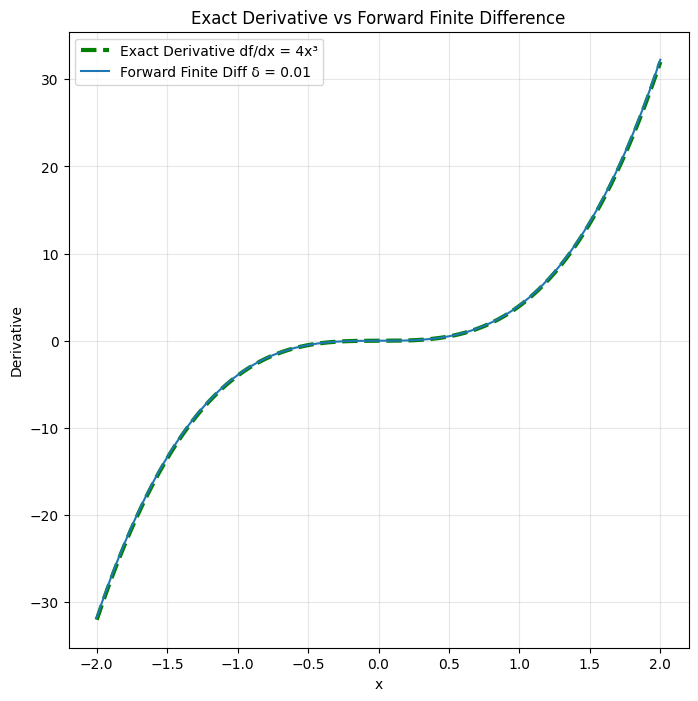

In [21]:
#question 1 (b)

x_vals = np.linspace(-2, 2, 400)
dlt = 0.01
f = lambda x: x**4
actual_der = lambda x: 4 * x**3
finite_diff = lambda x, dlt = dlt: (f(x + dlt) - f(x)) / dlt

exact_der = actual_der(x_vals)
approx_der = finite_diff(x_vals)

plt.figure(figsize=(8,8))
plt.plot(x_vals, exact_der, '--', label="Exact Derivative df/dx = 4x³", linewidth=3, color='green')
plt.plot(x_vals, approx_der, label="Forward Finite Diff δ = 0.01")
plt.xlabel('x')
plt.ylabel('Derivative')
plt.title("Exact Derivative vs Forward Finite Difference")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The following code snippet shows that the forward finite difference approximation closely follows the executive derivative computation.



/tmp/ipython-input-1368291292.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


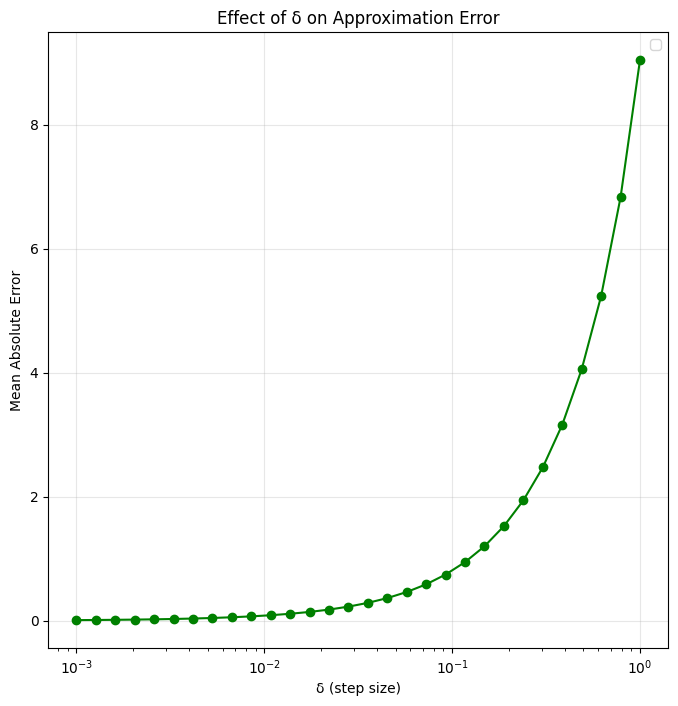

In [24]:
#question 1 (c)

dlt_vals = np.logspace(-3, 0, 30)
mae_vals = []

for d in dlt_vals:
  apprx = finite_diff(x_vals, d)
  mae = np.mean(np.abs(exact_der - apprx))
  mae_vals.append(mae)

plt.figure(figsize=(8,8))
plt.semilogx(dlt_vals, mae_vals, marker='o',color='green')
plt.xlabel('δ (step size)')
plt.ylabel('Mean Absolute Error')
plt.title("Effect of δ on Approximation Error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Below code snippet investigates the effect of δ in approximating the derivative.
* For very small δ, the precision error dominates and the truncation error
decreases
* For larger values of δ, error is large, and so is MAE.
* Optimal δ (around 10⁻² and 10⁻¹) balances the truncation error and the precision error, offering a better tradeoff between computational accuracy and numerical stability.


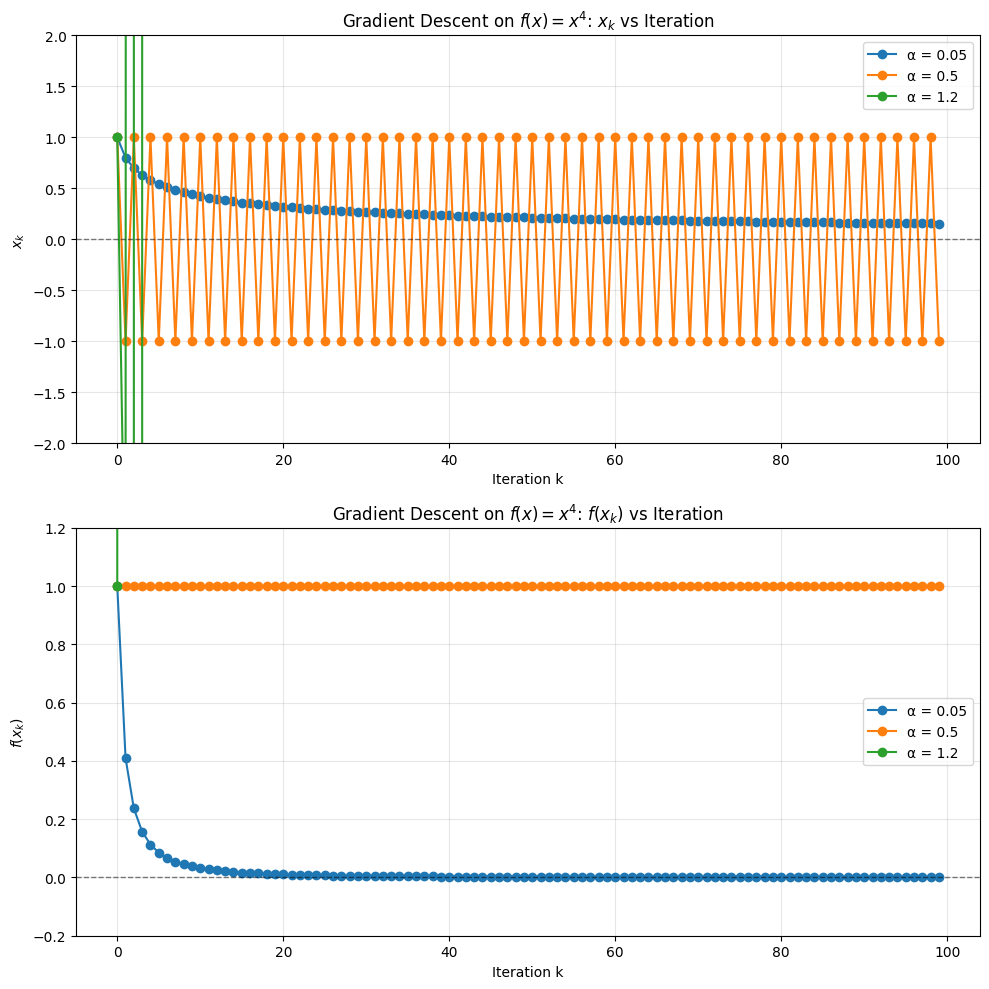

In [25]:
#question 1 (d) & (e)

def compute_grad_desc_q14(x0, alpha, f_prime, itrs=100, tol=1e-10):
    x_hist = [x0]
    for k in range(itrs - 1):
        x_next = x_hist[-1] - alpha * f_prime(x_hist[-1])
        x_hist.append(x_next)
        if abs(x_next) > 1e10:  # to detect divergence and handle overflow error
            break
    return np.array(x_hist)

f_q1 = lambda x: x**4
f_prime_q1 = lambda x: 4 * x**3
x0 = 1.0
alphas = [0.05, 0.5, 1.2]
results_q1 = {a: compute_grad_desc_q14(x0, a, f_prime_q1) for a in alphas}

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for alpha in alphas:
    x_hist = results_q1[alpha]
    axes[0].plot(range(len(x_hist)), x_hist, 'o-', label=f'α = {alpha}')

axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Iteration k')
axes[0].set_ylabel('$x_k$')
axes[0].set_title('Gradient Descent on $f(x) = x^4$: $x_k$ vs Iteration')
axes[0].set_ylim(-2, 2)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for alpha in alphas:
    x_hist = results_q1[alpha]
    f_hist = f_q1(x_hist)
    axes[1].plot(range(len(f_hist)), f_hist, 'o-', label=f'α = {alpha}')

axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Iteration k')
axes[1].set_ylabel('$f(x_k)$')
axes[1].set_title('Gradient Descent on $f(x) = x^4$: $f(x_k)$ vs Iteration')
axes[1].set_ylim(-0.2, 1.2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Question - 2

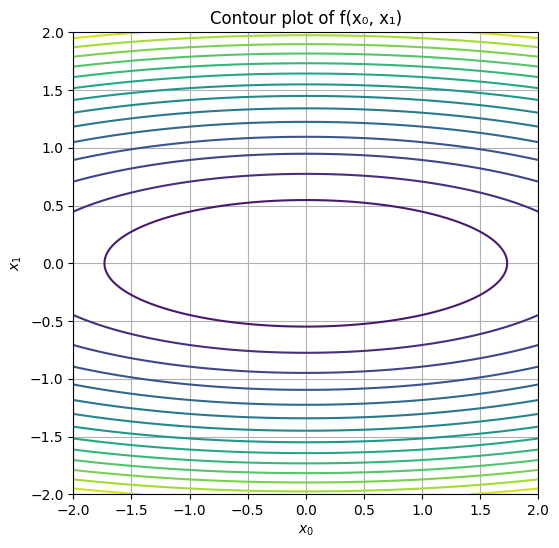

In [26]:
#question 2 (i) (a)

x0 = np.linspace(-2, 2, 400)
x1 = np.linspace(-2, 2, 400)
x0_mesh, x1_mesh = np.meshgrid(x0, x1)

Z_q21 = 0.5 * (x0_mesh**2 + 10 * x1_mesh**2)

plt.figure(figsize=(6,6))
cntrs = plt.contour(x0_mesh, x1_mesh, Z_q21, levels=20)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title('Contour plot of f(x₀, x₁)')
plt.grid(True)
plt.show()

* Contours are plotted over [−2,2]×[−2,2], which shows elliptical level sets.
* The contour plot is centered at (0,0), which is the global minimum.
* The ellipses are elongated along the x0 axis and the curvature is steeper in x1 axis, reflecting the fact that the coefficient of x1² is 10 times larger than x0², and the function is more sensitive to perturbations in x1 than x0.

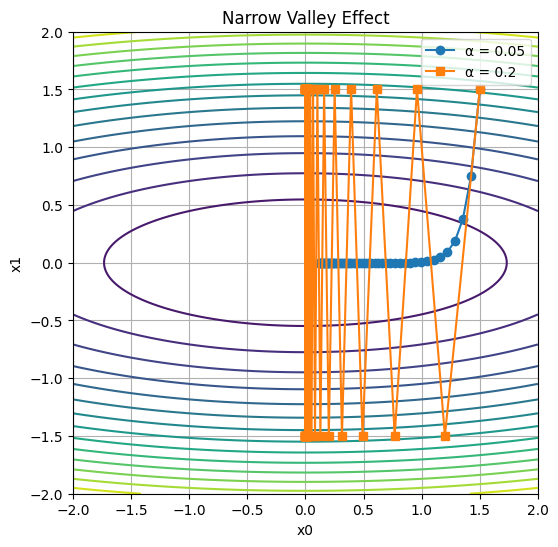

In [27]:
#question 2 (i) (b)

def compute_grad_desc_q21b(alpha, x0, itrs=50):
    x = np.zeros((itrs+1, 2))
    x[0] = x0

    for k in range(itrs):
        grad = np.array([x[k,0], 10*x[k,1]])
        x[k+1] = x[k] - alpha * grad

    return x

a5 = compute_grad_desc_q21b(0.05, np.array([1.5, 1.5]))
a2 = compute_grad_desc_q21b(0.2, np.array([1.5, 1.5]))

plt.figure(figsize=(6,6))
plt.contour(x0_mesh, x1_mesh, Z_q21, levels=20)
plt.plot(a5[:,0], a5[:,1], 'o-', label='α = 0.05')
plt.plot(a2[:,0], a2[:,1], 's-', label='α = 0.2')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('Narrow Valley Effect')
plt.legend()
plt.grid(True)
plt.show()


* The elongated ellipses in the contour plot create a narrow valley.
* The difference between the gradient magnitudes is significantly large (10:1), and so the gradient descent oscillates across the narrow valley rather than directly reaching the minimum.


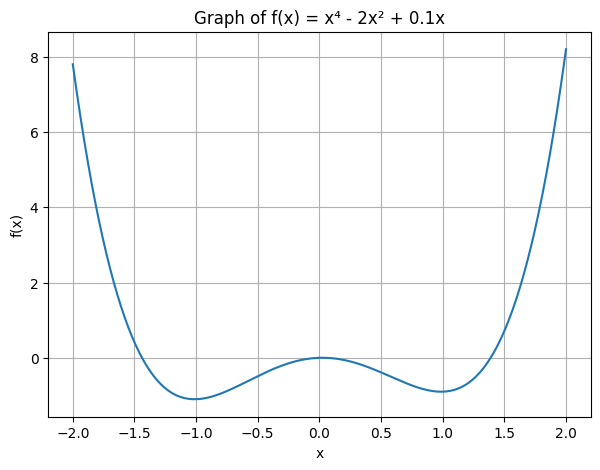

In [7]:
#question 2 (ii) (a)

x = np.linspace(-2, 2, 400)
f = x**4 - 2*x**2 + 0.1*x

plt.figure(figsize=(7,5))
plt.plot(x, f)
plt.title('Graph of f(x) = x⁴ - 2x² + 0.1x')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()

The given function is f(x)=x⁴−2x²+0.1x, and when plotted, it reveals a non-convex function with two local minima.

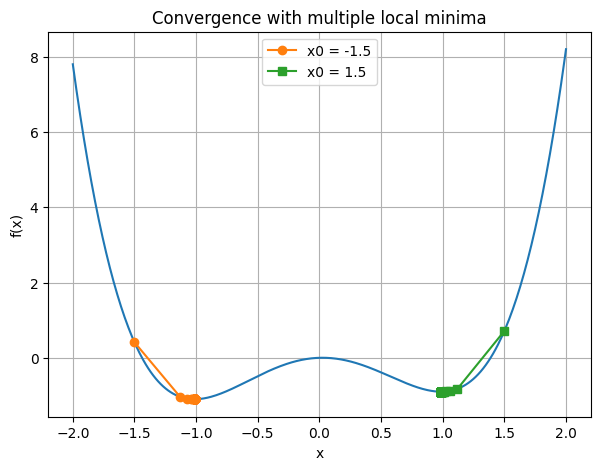

In [28]:
#question 2 (ii) (b)

def get_grad_q22(x):
    return 4*x**3 - 4*x + 0.1

def compute_grad_desc_q22b(alpha, x0, itrs=100):
    x = np.zeros(itrs+1)
    x[0] = x0

    for i in range(itrs):
        x[i+1] = x[i] - alpha * get_grad_q22(x[i])

    return x

x_neg = compute_grad_desc_q22b(0.05, -1.5)
x_pos = compute_grad_desc_q22b(0.05, 1.5)

x = np.linspace(-2, 2, 400)
f = x**4 - 2*x**2 + 0.1*x

plt.figure(figsize=(7,5))
plt.plot(x, f)
plt.plot(x_neg, x_neg**4 - 2*x_neg**2 + 0.1*x_neg, 'o-', label='x0 = -1.5')
plt.plot(x_pos, x_pos**4 - 2*x_pos**2 + 0.1*x_pos, 's-', label='x0 = 1.5')
plt.title('Convergence with multiple local minima')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

* Starting from x0 = -1.5, it converges to the left local minimum
* Starting from x0 = 1.5, it converges to the right local minimum
* We get two different solutions despite a symmetric distance between both the initialisation points.


##Question - 3

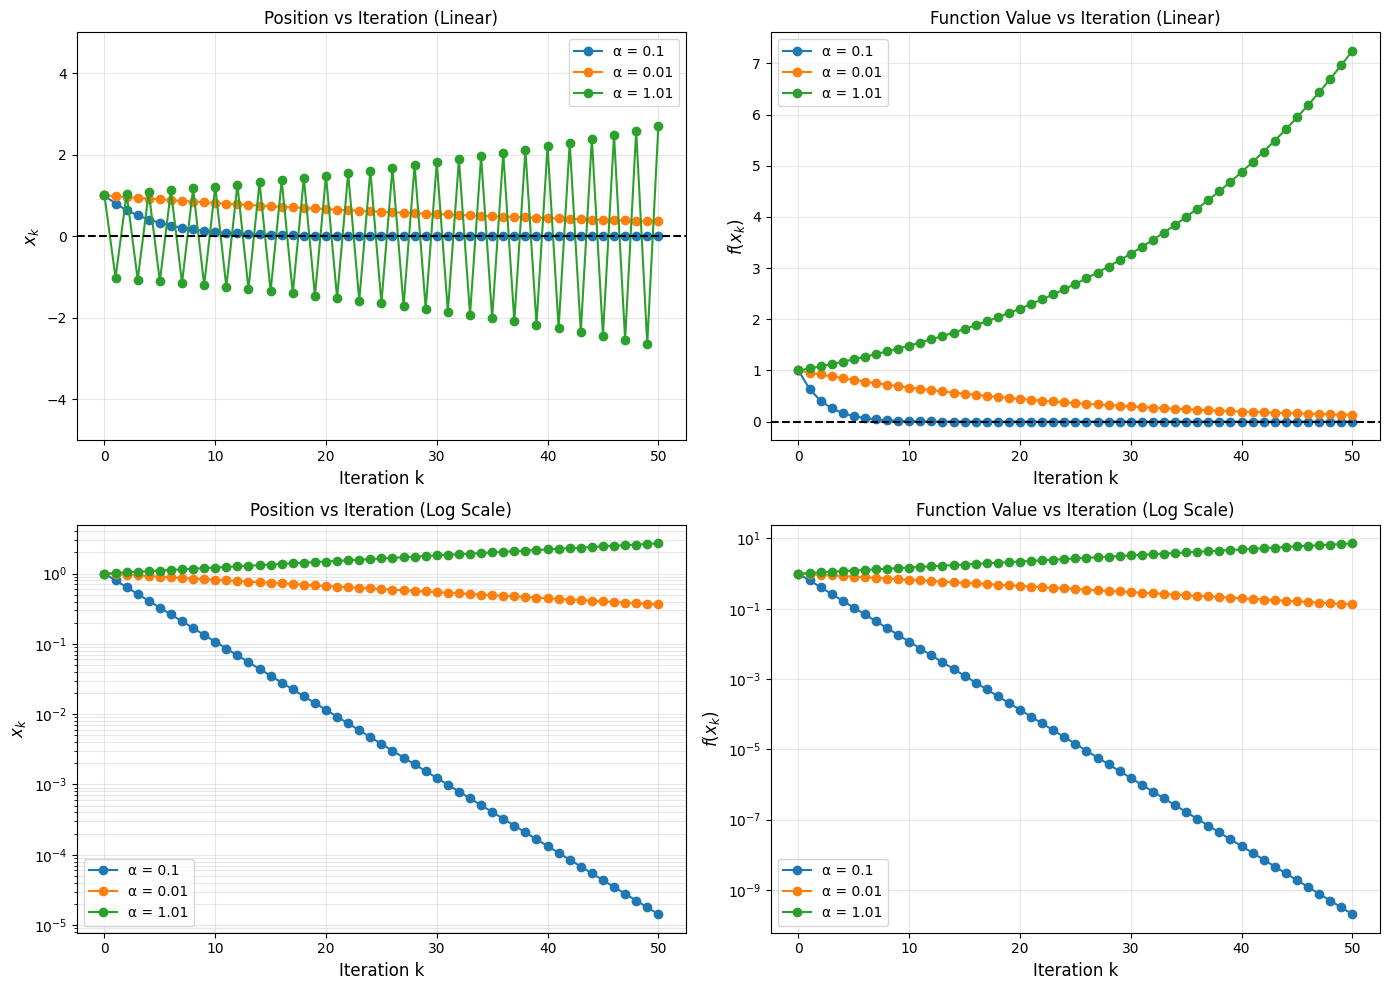

In [29]:
#question 3 (i)

def compute_grad_desc_q31(x0, alpha, itrs=50):
    x = np.zeros(itrs + 1)
    x[0] = x0

    for k in range(itrs):
        x[k+1] = x[k] - alpha * fp_q31(x[k])

        if abs(x[k+1]) > 1e10:
            x = x[:k+2]
            break

    return x

x0 = 1
alpha_vals = [0.1, 0.01, 1.01]
f_q31 = lambda x: x**2
fp_q31 = lambda x: 2*x
results = {}

for alpha in alpha_vals:
    results[alpha] = compute_grad_desc_q31(x0, alpha)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for alpha in alpha_vals:
    x_hist = results[alpha]
    axes[0, 0].plot(x_hist, 'o-', label=f'α = {alpha}')

axes[0, 0].axhline(y=0, color='black', linestyle='--')
axes[0, 0].set_xlabel('Iteration k', fontsize=12)
axes[0, 0].set_ylabel('$x_k$', fontsize=12)
axes[0, 0].set_title('Position vs Iteration (Linear)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([-5, 5])

for alpha in alpha_vals:
    x_hist = results[alpha]
    f_hist = f_q31(x_hist)
    axes[0, 1].plot(f_hist, 'o-', label=f'α = {alpha}')

axes[0, 1].axhline(y=0, color='black', linestyle='--')
axes[0, 1].set_xlabel('Iteration k', fontsize=12)
axes[0, 1].set_ylabel('$f(x_k)$', fontsize=12)
axes[0, 1].set_title('Function Value vs Iteration (Linear)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for alpha in alpha_vals:
    x_hist = results[alpha]
    abs_x = np.abs(x_hist)
    mask = abs_x > 0
    if np.any(mask):
        axes[1, 0].semilogy(np.where(mask)[0], abs_x[mask], 'o-', label=f'α = {alpha}')

axes[1, 0].set_xlabel('Iteration k', fontsize=12)
axes[1, 0].set_ylabel('$x_k$', fontsize=12)
axes[1, 0].set_title('Position vs Iteration (Log Scale)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

for alpha in alpha_vals:
    x_hist = results[alpha]
    f_hist = f_q31(x_hist)
    mask = f_hist > 0
    if np.any(mask):
        axes[1, 1].semilogy(np.where(mask)[0], f_hist[mask], 'o-', label=f'α = {alpha}')

axes[1, 1].set_xlabel('Iteration k', fontsize=12)
axes[1, 1].set_ylabel('$f(x_k)$', fontsize=12)
axes[1, 1].set_title('Function Value vs Iteration (Log Scale)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


* For ⍺ = 0.1, the reduction factor is xk = (1 - 0.2k) = 0.8k. Since the magnitude is less than 1, xk and f(xk) decrease monotonically and quickly converge to zero.
* For ⍺ = 0.01, the magnitude of the reduction factor is 0.98, very close to 1. This converges stably but very slowly; the log plot below shows a shallow slope and the position decreases gradually
* For ⍺ = 1.01, the reduction factor is -1.02, and its magnitude exceeds 1. Here the divergence oscillates, exponentially grows in magnitude and fails miserably, and also the amplitude increases over iterations.



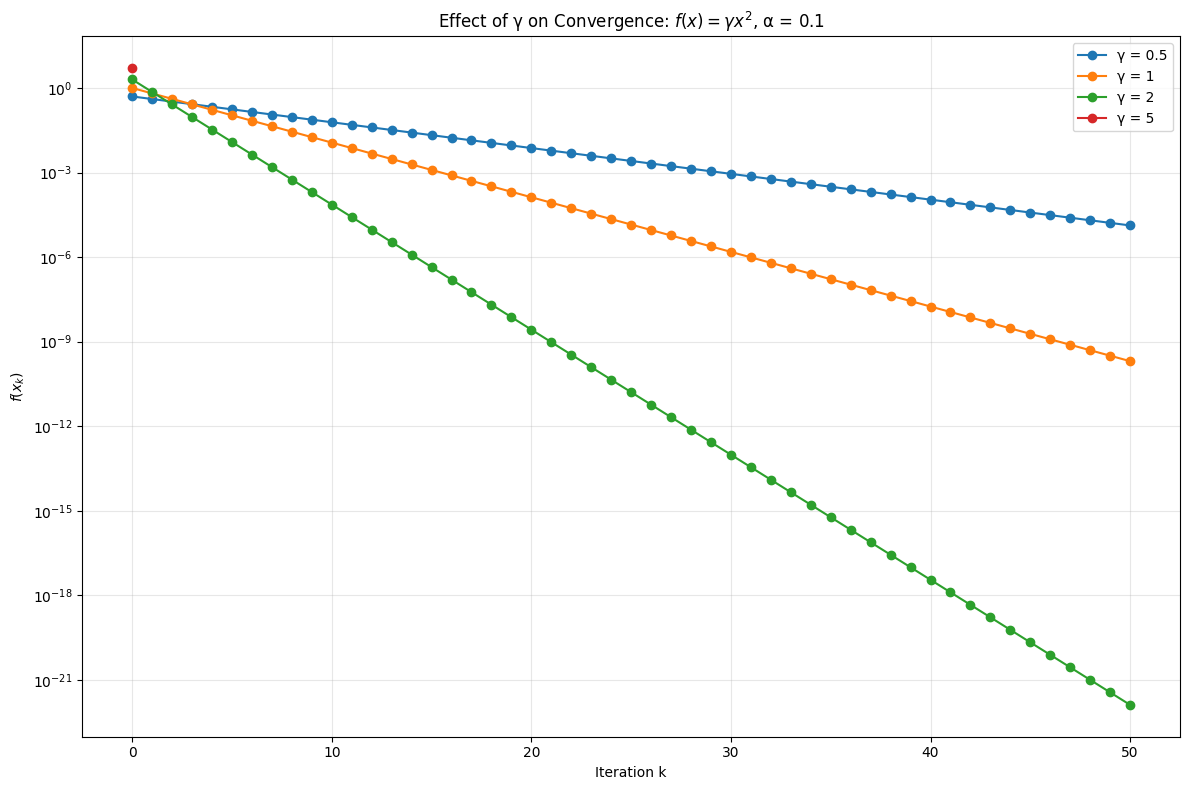

In [30]:
#question 3 (ii)

def compute_grad_desc_q32(x0, alpha, gamma, itrs=50):
    x = np.zeros(itrs + 1)
    x[0] = x0

    for k in range(itrs):
        x[k+1] = x[k] - alpha * fpg_q32(x[k], gamma)
        if abs(x[k+1]) > 1e10:
            x = x[:k+2]
            break

    return x

x0 = 1
alpha = 0.1
gamma_vals = [0.5, 1, 2, 5]
fg_q32 = lambda x, gamma: gamma * x**2
fpg_q32 = lambda x, gamma: 2 * gamma * x
results = {}

for g in gamma_vals:
    x_hist = compute_grad_desc_q32(x0, alpha, g)
    results[g] = x_hist

plt.figure(figsize=(12, 8))

for g in gamma_vals:
    x_hist = results[g]
    f_hist = fg_q32(x_hist, g)
    mask = f_hist > 0
    if np.any(mask):
        plt.semilogy(np.where(mask)[0], f_hist[mask], 'o-', label=f'γ = {g}')

plt.xlabel('Iteration k')
plt.ylabel('$f(x_k)$')
plt.title('Effect of γ on Convergence: $f(x) = γx^2$, α = 0.1')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

* When γ = 0.5, the factor is so close to 1, and hence a slow convergence is observed.
* When γ = {1,2}, a faster exponential decay corresponding to steeper slopes is observed.
* When γ = 5, the factor becomes zero, so the function jumps directly to x1 = 0 instantaneously, and a near-immediate convergence is observed.

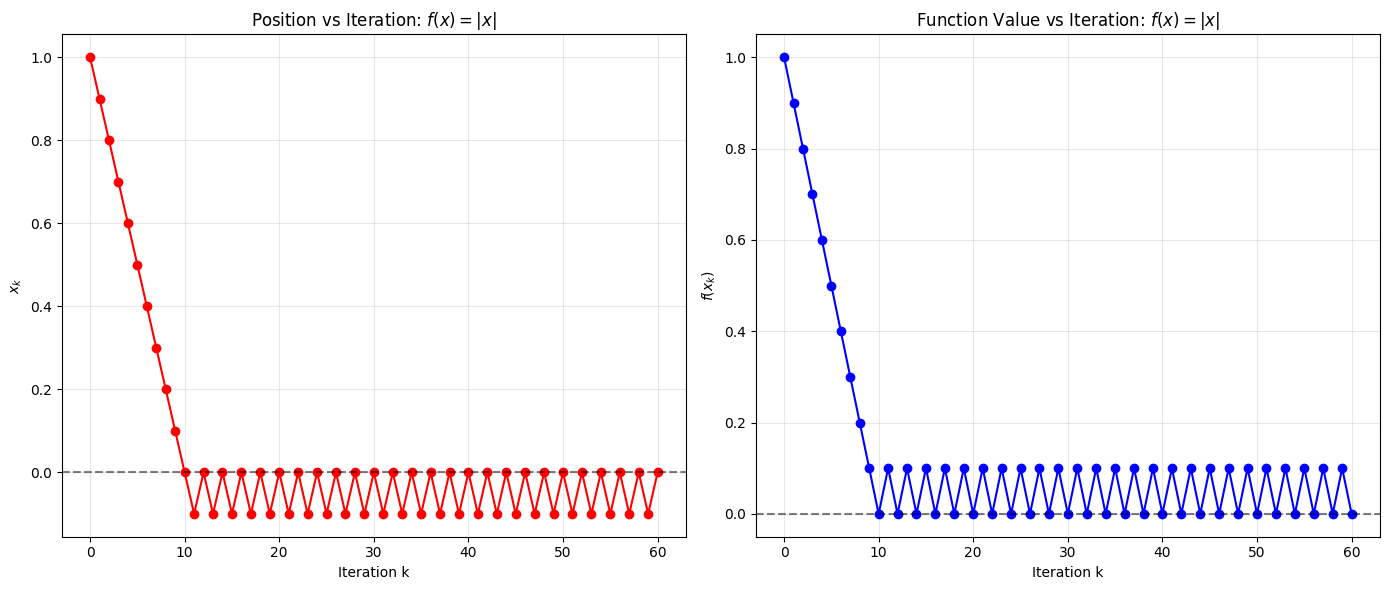

In [31]:
#question 3 (iii)

def subgrad(x):
    return np.sign(x)

def compute_grd_desc_q33(x0, alpha, itrs=60):
    x = np.zeros(itrs + 1)
    x[0] = x0

    for k in range(itrs):
        g = subgrad(x[k])
        x[k+1] = x[k] - alpha * g

    return x

x0 = 1
alpha = 0.1
itrs = 60
f = lambda x: np.abs(x)
x_hist = compute_grd_desc_q33(x0, alpha, itrs)
f_hist = f(x_hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(x_hist, 'o-', color='red')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Iteration k')
axes[0].set_ylabel('$x_k$')
axes[0].set_title('Position vs Iteration: $f(x) = |x|$')
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_hist, 'o-', color='blue')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Iteration k')
axes[1].set_ylabel('$f(x_k)$')
axes[1].set_title('Function Value vs Iteration: $f(x) = |x|$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* The function decreases linearly towards zero.
* The sign flips when it crosses zero.
* The iterations oscillate between positive and negative values around zero


##Question - 4

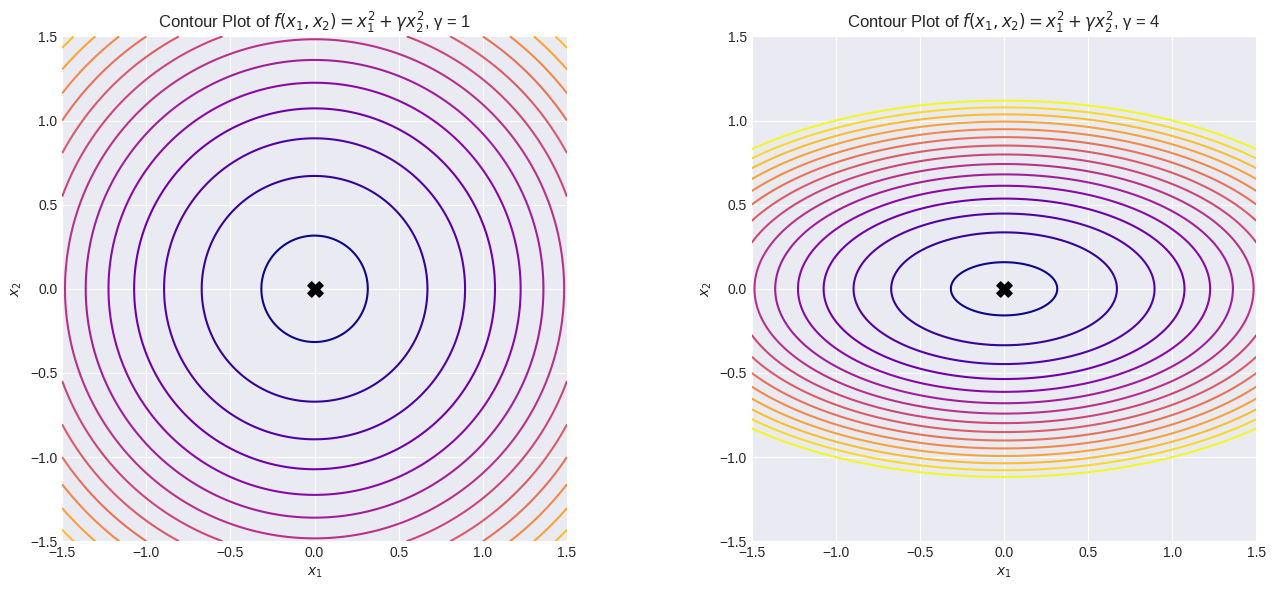

In [34]:
#question 4 (a)

plt.style.use('seaborn-v0_8-darkgrid')

x1_range = np.linspace(-1.5, 1.5, 400)
x2_range = np.linspace(-1.5, 1.5, 400)
x1_mesh, x2_mesh = np.meshgrid(x1_range, x2_range)

gamma_vals = [1, 4]
f_q4a = lambda x1, x2, gamma: x1**2 + gamma * x2**2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, gamma in enumerate(gamma_vals):
    Z = f_q4a(x1_mesh, x2_mesh, gamma)

    contours = axes[idx].contour(
        x1_mesh, x2_mesh, Z,
        levels=np.linspace(0.1, 5, 15),
        cmap='plasma',
    )

    axes[idx].scatter(0, 0, s=120, c='black', marker='X')
    axes[idx].set_xlabel('$x_1$')
    axes[idx].set_ylabel('$x_2$')
    axes[idx].set_title(f'Contour Plot of $f(x_1, x_2) = x_1^2 + γx_2^2$, γ = {gamma}')
    axes[idx].set_aspect('equal')
    axes[idx].set_xlim(-1.5, 1.5)
    axes[idx].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()


* For γ = 1, the level sets are perfect circles centred at (0,0), and the curvature is same in both directions.
* For γ = 4, the level sets are ellipses elongated in the x1 axis and compressed along x2 axis, indicating a steeper curvature in x2 axis dn hence forming a narrow valley.

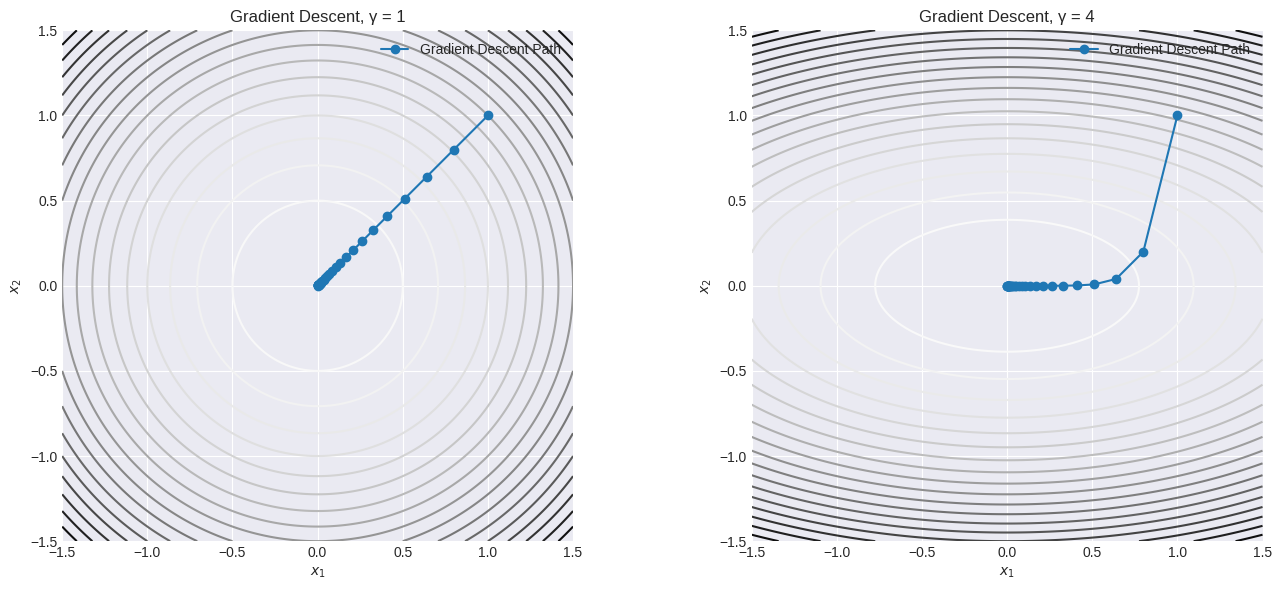

In [35]:
#question 4 (b)

def compute_grad_desc_q42(gamma, alpha=0.1, x0=np.array([1.0, 1.0]), itrs=30):
    pth = np.zeros((itrs+1, 2))
    pth[0] = x0

    for k in range(itrs):
        pth[k+1] = pth[k] - alpha * grad_f_q4b(pth[k], gamma)

    return pth

gamma_values = [1, 4]
f_q4b = lambda x1, x2, gamma: x1**2 + gamma * x2**2
grad_f_q4b = lambda x, gamma: np.array([2*x[0], 2*gamma*x[1]])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, gamma in enumerate(gamma_values):
    Z_q4b = f_q4b(x1_mesh, x2_mesh, gamma)
    axes[idx].contour(x1_mesh, x2_mesh, Z_q4b, levels=20)
    path = compute_grad_desc_q42(gamma)
    axes[idx].plot(path[:,0], path[:,1], 'o-', label='Gradient Descent Path')
    axes[idx].set_title(f'Gradient Descent, γ = {gamma}')
    axes[idx].set_xlabel('$x_1$')
    axes[idx].set_ylabel('$x_2$')
    axes[idx].set_aspect('equal')
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()


* For γ = 1, the gradient descent trajectory directly moves towards zero in a straight path, since the level sets are isotopic. It exhibits a smooth exponential convergence without oscillations.
* For  γ = 4, the shrinkage factors end up as x1 = 0.8 and x2 = 1 - 0.8 = 0.2. Now here the trajectory shows a zigzag path across the narrow valley and is curved due to different curvatures in different directions. The path rapidly collapses vertically, followed by a slow horizontal movement.  It is because the gradient component is 4 times larger in the x2 direction, leading to overshoot perpendicularly in the narrow valley.



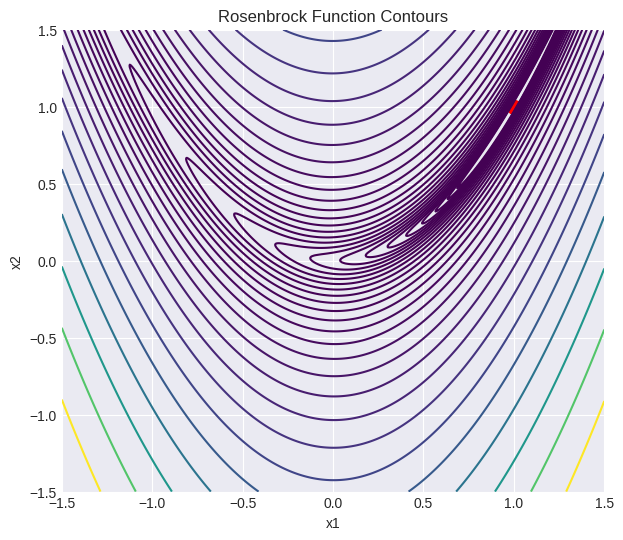

In [36]:
#question 4 (c)

def get_rb(x1, x2):
    return (1 - x1)**2 + 100*(x2 - x1**2)**2

Z_q4c = get_rb(x1_mesh, x2_mesh)

plt.figure(figsize=(7,6))
plt.contour(x1_mesh, x2_mesh, Z_q4c, levels=np.logspace(-1, 3, 30), cmap='viridis')
plt.scatter(1, 1, c='red', s=100)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Rosenbrock Function Contours')
plt.grid(True)
plt.show()

The given function is f(x1,x2)=(1−x1)²+100(x2−x1²)², and the contours are plotted over [-2,2] x [-1,3]. This function is specifically called a Rosenbrock function because of its curved valley shape. It has a global minimum at (1,1)

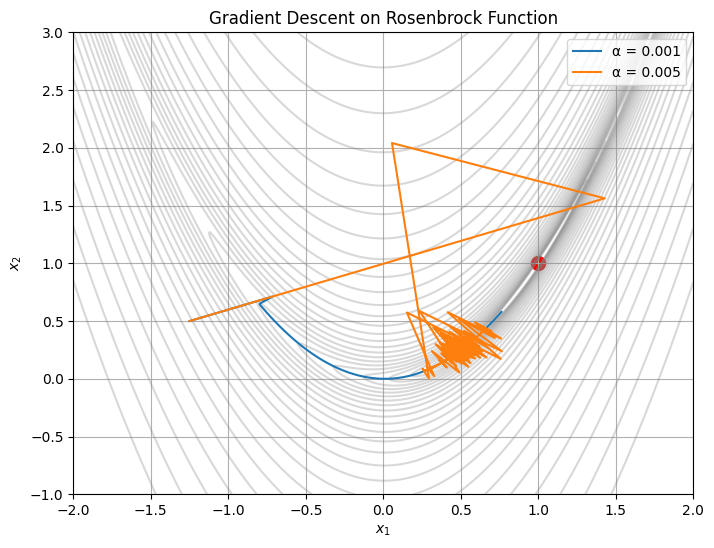

In [18]:
#question 4 (d)

def get_grad_rb(x):
    dfdx1 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    dfdx2 = 200*(x[1] - x[0]**2)
    return np.array([dfdx1, dfdx2])

def compute_grad_desc_q44(alpha, x0, itrs=2000):
    pth = np.zeros((itrs+1, 2))
    pth[0] = x0

    for k in range(itrs):
        pth[k+1] = pth[k] - alpha * get_grad_rb(pth[k])

    return pth

x0 = np.array([-1.25, 0.5])

a_1 = compute_grad_desc_q44(0.001, x0)
a_5 = compute_grad_desc_q44(0.005, x0)

Z = (1 - x1_mesh)**2 + 100 * (x2_mesh - x1_mesh**2)**2
rb = lambda x: (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

plt.figure(figsize=(8,6))
plt.contour(x1_mesh, x2_mesh, Z, levels=np.logspace(-1, 3, 30), colors='gray', alpha=0.3)
plt.plot(a_1[:,0], a_1[:,1], label='α = 0.001')
plt.plot(a_5[:,0], a_5[:,1], label='α = 0.005')
plt.scatter(1, 1, c='red', s=100)
plt.title('Gradient Descent on Rosenbrock Function')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()


* For ⍺ = 0.001, the convergence is extremely slow and stable as the gradient descent trajectory slowly follows the curved valley, with small steps in both directions.
* For ⍺ = 0.005, the convergence takes much larger steps, overshoots across the narrow valley and exhibits strong oscillations before clustering near the bottom. It shows how a large step size in an ill-conditioned curved valley can affect stability.